# MNIST Handwritten Digit Recognition Using CNN

## 1. Import Required Libraries
- Import TensorFlow/Keras for building and training the CNN model.
- Import NumPy for numerical operations.
- Import Matplotlib for displaying images and plotting graphs.

## 2. Load the MNIST Dataset
- Load the MNIST handwritten digit dataset.
- The dataset contains handwritten digits from 0 to 9.
- Each image has a size of 28 × 28 pixels.
- Divide the dataset into training and testing data.

## 3. Preprocess the Data
- Normalize pixel values from 0–255 to 0–1.
- Reshape the images to include the grayscale channel.
- The final image shape is 28 × 28 × 1.

## 4. Build the CNN Model
- Use Convolutional layers to extract important features from images.
- Use MaxPooling layers to reduce the image dimensions.
- Use Flatten to convert feature maps into a one-dimensional vector.
- Use Dense layers to learn patterns.
- Use the output layer to classify the image into one of 10 digits (0–9).

## 5. Compile the Model
- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Evaluation Metric: Accuracy

## 6. Train the Model
- Train the CNN using the training dataset.
- Use multiple epochs to allow the model to learn patterns.
- Monitor training and validation accuracy and loss.

## 7. Evaluate the Model
- Evaluate the trained model using the unseen test dataset.
- Calculate test loss and test accuracy.

## 8. Predict Test Images
- Select the first 10 test images.
- Use the trained CNN to predict their digits.
- Compare the predicted digits with the actual labels.

## 9. Visualize Predictions
- Display the first 10 test images.
- Show the predicted digit and actual digit for each image.
- This helps us visually check the model's predictions.

## 10. Plot Training and Validation Accuracy
- Plot training accuracy and validation accuracy for each epoch.
- Use the graph to observe the model's learning performance.
- A large difference between training and validation accuracy may indicate overfitting.

## 11. Plot Training and Validation Loss
- Plot training loss and validation loss for each epoch.
- Lower loss generally indicates better model performance.
- Increasing validation loss while training loss decreases may indicate overfitting.

## 12. Test a New Handwritten Image
- Load a new handwritten digit image.
- Resize the image to 28 × 28 pixels.
- Convert the image to grayscale.
- Normalize the pixel values.
- Reshape the image according to the CNN input format.
- Pass the image to the trained model for prediction.

## 13. Display the Final Prediction
- Display the new handwritten digit image.
- Print the digit predicted by the CNN model.

## Complete Workflow

MNIST Dataset
↓
Load Dataset
↓
Data Preprocessing
↓
Normalize Pixel Values
↓
Reshape Images
↓
Build CNN Model
↓
Compile Model
↓
Train CNN
↓
Evaluate Model
↓
Predict Test Images
↓
Visualize Predictions
↓
Plot Accuracy and Loss
↓
Load New Handwritten Image
↓
Preprocess New Image
↓
CNN Prediction
↓
Predicted Digit (0–9)

## Project Summary

This project uses a Convolutional Neural Network (CNN) to recognize handwritten digits from 0 to 9 using the MNIST dataset. The trained model is also tested on a new handwritten digit image to determine which digit it represents.

In [1]:
import tensorflow as tf
# Function: TensorFlow is used to build, train, and evaluate machine learning/deep learning models.

import matplotlib.pyplot as plt
# Function: Matplotlib is used to create graphs and visualize data, such as accuracy and loss curves.

import numpy as np
# Function: NumPy is used for numerical calculations and working with arrays/matrices.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Function:
# Loads the MNIST handwritten digit dataset( approx. 70000 images of digits)
# x_train = training images
# y_train = correct labels for training images
# x_test  = testing images
# y_test  = correct labels for testing images

print("Training data:", x_train.shape)
# Function: Displays the size/shape of the training images.

print("Testing data:", x_test.shape)
# Function: Displays the size/shape of the testing images.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


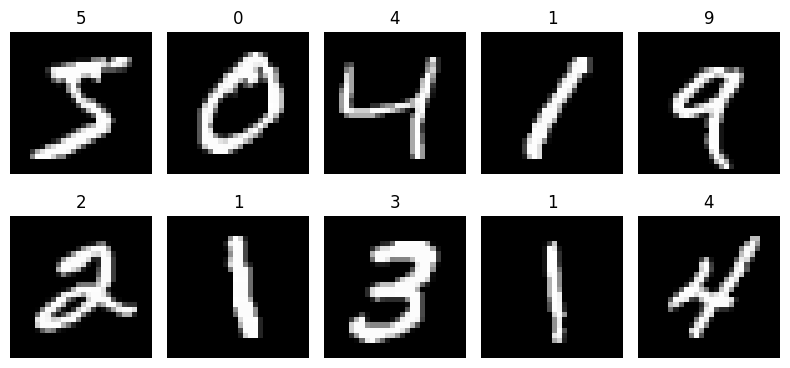

In [3]:
plt.figure(figsize=(8, 4))
# Function: Creates a figure where the images will be displayed.

for i in range(10):
    # Function: Repeats the following instructions for images 0 to 9.

    plt.subplot(2, 5, i + 1)
    # Function: Creates a grid of 2 rows and 5 columns for displaying images.

    plt.imshow(x_train[i], cmap="gray")
    # Function: Displays the handwritten image in grayscale.

    plt.title(y_train[i])
    # Function: Displays the actual digit/label above the image.

    plt.axis("off")
    # Function: Hides the x-axis and y-axis.

plt.tight_layout()
# Function: Automatically adjusts spacing between images.

plt.show()
# Function: Displays the complete figure.

In [4]:
x_train = x_train.astype("float32") / 255.0
# Function: Converts pixel values to floating-point numbers
# and normalizes them from 0-255 to 0-1.

x_test = x_test.astype("float32") / 255.0
# Function: Performs the same normalization on the test images.

x_train = x_train[..., np.newaxis]
# Function: Adds a channel dimension to training images.
# Shape changes from (28, 28) to (28, 28, 1).

x_test = x_test[..., np.newaxis]
# Function: Adds a channel dimension to testing images.

print(x_train.shape)
# Function: Displays the new shape of the training data.

(60000, 28, 28, 1)


In [5]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),
    # Function: Conv2D detects important patterns such as edges and shapes.
    # 32 = number of filters.
    # (3,3) = size of each filter.
    # ReLU = activation function.
    # input_shape = image size: 28 x 28 with 1 grayscale channel.

    tf.keras.layers.MaxPooling2D((2, 2)),
    # Function: Max Pooling reduces the image/feature-map size
    # while keeping important information.

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    # Function: Second convolution layer finds more complex patterns.
    # 64 = number of filters.
    # (3,3) = filter size.
    # ReLU = activation function.

    tf.keras.layers.MaxPooling2D((2, 2)),
    # Function: Further reduces the feature-map size.

    tf.keras.layers.Flatten(),
    # Function: Converts the 2D feature maps into a 1D list/vector.

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),
    # Function: Dense layer learns combinations of the extracted features.
    # 64 = number of neurons.
    # ReLU = activation function.

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
    # Function: Final output layer.
    # 10 neurons represent digits 0,1,2,...,9.
    # Softmax converts outputs into probabilities.
])

model.summary()
# Function: Displays the architecture and number of parameters
# of the CNN model.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# SUMMARY:
# This cell compiles the neural network model and prepares it
# for training by defining the optimizer, loss function, and
# accuracy metric.
# ============================================================

# Function: compile() configures the model for training
model.compile(

    # Function: optimizer controls how the model updates
    # its weights to reduce the loss
    optimizer="adam",

    # Function: loss measures the difference between the
    # model's predicted class and the actual class
    # sparse_categorical_crossentropy is used for
    # multi-class classification with integer labels
    loss="sparse_categorical_crossentropy",

    # Function: metrics specifies how model performance
    # will be evaluated during training
    # accuracy = percentage of correctly classified images
    metrics=["accuracy"]
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9497 - loss: 0.1622 - val_accuracy: 0.9882 - val_loss: 0.0431
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9843 - loss: 0.0502 - val_accuracy: 0.9892 - val_loss: 0.0360
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9886 - loss: 0.0358 - val_accuracy: 0.9883 - val_loss: 0.0434
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9882 - val_loss: 0.0396
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9900 - val_loss: 0.0403


In [8]:
# ============================================================
# SUMMARY:
# This cell evaluates the trained model on the test dataset
# and displays the model's accuracy on unseen test images.
# ============================================================

# Function: evaluate() tests the trained model using x_test
# and y_test and returns the test loss and test accuracy
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Function: print() displays the test accuracy on the screen
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9882 - loss: 0.0436
Test accuracy: 0.9882000088691711


In [9]:
# ============================================================
# SUMMARY:
# This cell uses the trained model to predict the digits of
# the first 10 test images and compares the predicted digits
# with their actual labels.
# ============================================================

# Function: predict() uses the trained model to make predictions
# x_test[:10] selects the first 10 test images
# verbose=0 hides the prediction progress bar
predictions = model.predict(x_test[:10], verbose=0)

# Function: argmax() finds the class with the highest probability
# axis=1 means we find the highest probability for each image
# This gives the predicted digit (0 to 9)
predicted_digits = np.argmax(predictions, axis=1)

# Function: print() displays the digits predicted by the model
print("Predicted:", predicted_digits)

# Function: print() displays the actual/correct labels
# y_test[:10] selects the actual labels of the first 10 images
print("Actual:   ", y_test[:10])

Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


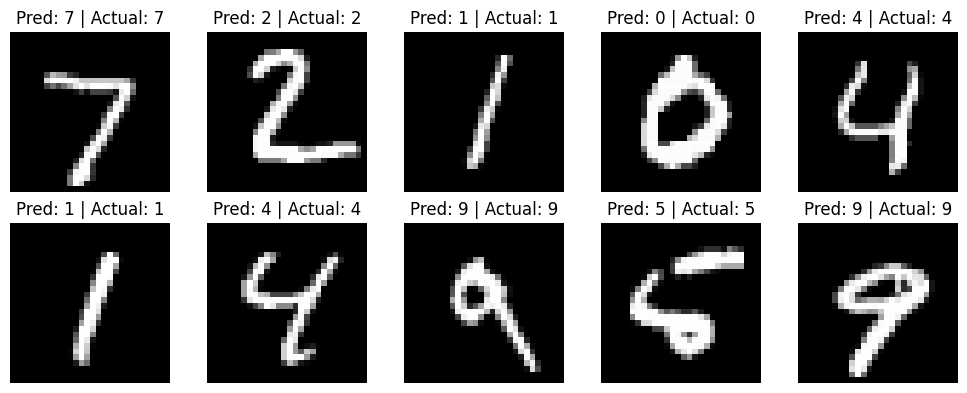

In [10]:
# ============================================================
# SUMMARY:
# This cell displays the first 10 test images in a 2×5 grid
# and shows the model's predicted digit and the actual digit
# above each image.
# ============================================================

# Function: figure() creates a new figure/window for plotting
# figsize=(10, 4) sets the width and height of the figure
plt.figure(figsize=(10, 4))

# Function: range(10) generates numbers from 0 to 9
# This loop processes and displays the first 10 test images
for i in range(10):

    # Function: subplot() divides the figure into 2 rows
    # and 5 columns and selects the current position
    plt.subplot(2, 5, i + 1)

    # Function: imshow() displays the image
    # squeeze() removes unnecessary dimensions
    # cmap="gray" displays the image in grayscale
    plt.imshow(x_test[i].squeeze(), cmap="gray")

    # Function: title() displays the predicted and actual labels
    plt.title(f"Pred: {predicted_digits[i]} | Actual: {y_test[i]}")

    # Function: axis("off") hides the x-axis and y-axis
    plt.axis("off")

# Function: tight_layout() automatically adjusts spacing
# between the images and titles
plt.tight_layout()

# Function: show() displays the complete figure
plt.show()

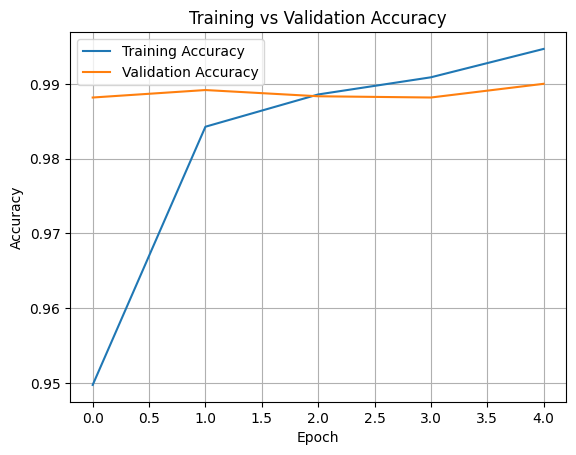

In [11]:
# ============================================================
# SUMMARY:
# This cell plots the training and validation accuracy of the
# model for each epoch. It helps us see whether the model is
# learning well and whether overfitting may be occurring.
# ============================================================

# Function: plot() draws the training accuracy values
# history.history["accuracy"] contains accuracy for each epoch
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Function: plot() draws the validation accuracy values
# history.history["val_accuracy"] contains validation accuracy
# for each epoch
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Function: xlabel() gives a label to the x-axis
plt.xlabel("Epoch")

# Function: ylabel() gives a label to the y-axis
plt.ylabel("Accuracy")

# Function: title() gives a title to the graph
plt.title("Training vs Validation Accuracy")

# Function: legend() displays the labels of both lines
plt.legend()

# Function: grid() adds grid lines to make the graph easier to read
plt.grid(True)

# Function: show() displays the completed graph
plt.show()

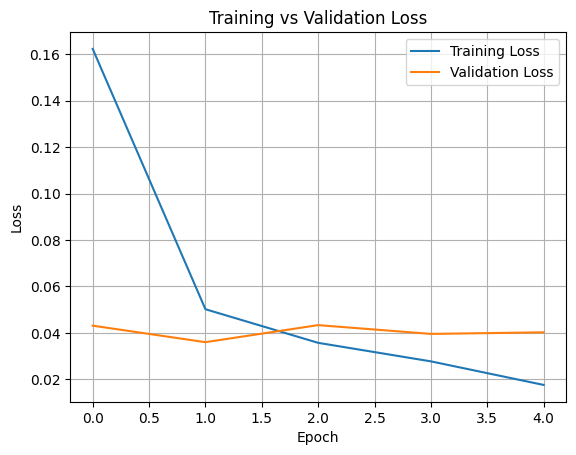

In [12]:
# ============================================================
# SUMMARY:
# This cell plots the training and validation loss for each
# epoch. It helps us understand how the model's error changes
# during training and whether the model is overfitting.
# ============================================================

# Function: plot() draws the training loss values
# history.history["loss"] contains the training loss for each epoch
plt.plot(history.history["loss"], label="Training Loss")

# Function: plot() draws the validation loss values
# history.history["val_loss"] contains the validation loss
# for each epoch
plt.plot(history.history["val_loss"], label="Validation Loss")

# Function: xlabel() gives a label to the x-axis
plt.xlabel("Epoch")

# Function: ylabel() gives a label to the y-axis
plt.ylabel("Loss")

# Function: title() gives a title to the graph
plt.title("Training vs Validation Loss")

# Function: legend() displays the labels of both lines
plt.legend()

# Function: grid() adds grid lines to make the graph easier to read
plt.grid(True)

# Function: show() displays the completed graph
plt.show()

Testing

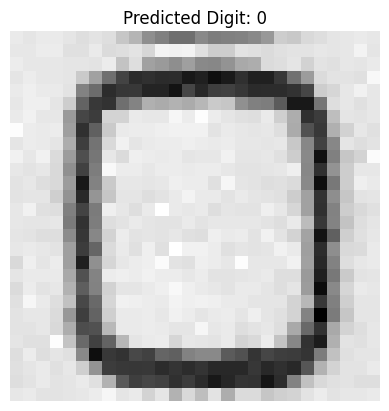

Predicted Digit: 0


In [13]:
# ============================================================
# SUMMARY:
# This cell loads a single handwritten digit image, prepares it
# in the same format used during MNIST model training, sends it
# to the trained CNN model, and displays the predicted digit.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# ------------------------------------------------------------
# Function: load_img()
# Loads the image from the given path and resizes it to 28×28
# because MNIST images are 28×28 pixels.
# grayscale=True converts the image to grayscale.
# ------------------------------------------------------------
image_path = "/content/img001-00001 (2).png"

img = load_img(
    image_path,
    target_size=(28, 28),
    color_mode="grayscale"
)

# ------------------------------------------------------------
# Function: img_to_array()
# Converts the image into a NumPy array.
# ------------------------------------------------------------
img_array = img_to_array(img)

# ------------------------------------------------------------
# Normalize pixel values from 0-255 to 0-1
# This should match the preprocessing used during training.
# ------------------------------------------------------------
img_array = img_array / 255.0

# ------------------------------------------------------------
# Function: reshape()
# Adds the batch dimension required by the CNN.
# Shape becomes: (1, 28, 28, 1)
# ------------------------------------------------------------
img_array = img_array.reshape(1, 28, 28, 1)

# ------------------------------------------------------------
# Function: model.predict()
# Uses the trained CNN model to predict the digit.
# ------------------------------------------------------------
prediction = model.predict(img_array, verbose=0)

# ------------------------------------------------------------
# Function: argmax()
# Finds the digit with the highest predicted probability.
# ------------------------------------------------------------
predicted_digit = np.argmax(prediction, axis=1)[0]

# ------------------------------------------------------------
# Display the image
# ------------------------------------------------------------
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Predicted Digit: {predicted_digit}")
plt.show()

# ------------------------------------------------------------
# Display the final prediction
# ------------------------------------------------------------
print("Predicted Digit:", predicted_digit)